# 05 — Robustness Analysis (Example)

Parameter sensitivity, bootstrap resampling, stress tests and a Monte Carlo
permutation check for the example cross-sectional momentum strategy. The goal is to find **stable regions** of parameter space and to gauge
whether the result could plausibly be noise — not to find one lucky optimum.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from quantlab.config import ExperimentConfig
from quantlab.data.loader import DataLoader
from quantlab.backtesting.runner import run_backtest_from_config
from quantlab.validation.parameter_sensitivity import (
    run_parameter_sensitivity, sensitivity_heatmap_data,
)
from quantlab.validation.bootstrap import bootstrap_returns
from quantlab.validation.robustness import run_stress_tests, monte_carlo_permutation

config = ExperimentConfig.from_yaml("../configs/momentum_sp500.yaml")
data, report = DataLoader().load(config)
result = run_backtest_from_config(data, config, data_quality_report=report)
result.metrics["sharpe_ratio"], result.metrics["cagr"]


(0.44371649849802863, 0.05747479854942217)

## Parameter sensitivity: lookback period x top fraction

In [2]:
sensitivity = run_parameter_sensitivity(
    data, config,
    parameter_x="lookback_period", values_x=[126, 189, 252, 315],
    parameter_y="top_fraction", values_y=[0.25, 0.375, 0.5, 0.625],
)
heat = sensitivity_heatmap_data(sensitivity, "lookback_period", "top_fraction", "sharpe")
heat


lookback_period,126,189,252,315
top_fraction,,,,
0.250,0.282722,0.346163,0.443716,0.420907
0.375,0.501479,0.553154,0.688104,0.650963
0.500,0.526569,0.484626,0.686852,0.694514
0.625,0.553919,0.576572,0.690520,0.704114


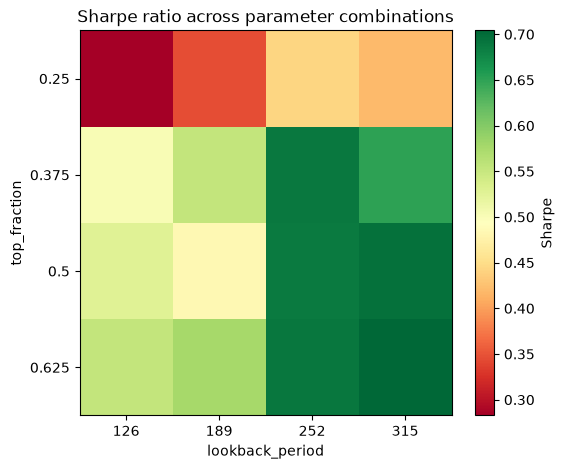

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(heat.to_numpy(dtype=float), cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
ax.set_xlabel("lookback_period"); ax.set_ylabel("top_fraction")
ax.set_title("Sharpe ratio across parameter combinations")
fig.colorbar(im, ax=ax, label="Sharpe")
plt.show()


The goal here is a broad plateau of reasonable Sharpe ratios, not a single
sharp peak — a plateau suggests the result isn't a fragile accident of one
specific parameter choice.


## Bootstrap distribution of CAGR, Sharpe, maximum drawdown

This test asks a simple question: would the strategy's results remain similar
if the same types of gains and losses had occurred in a different sequence?

QuantLab starts from the strategy's historical net daily returns. For each of
1,000 simulations, it selects a random starting date and copies 21 consecutive
returns, roughly one trading month. It repeats this process until it has built
a synthetic history with the same length as the original one.

A historical block may appear several times in one simulation or may not be
selected at all. Sampling consecutive blocks, rather than isolated days,
preserves some short periods of high volatility, low volatility, gains and
losses.

QuantLab then calculates the CAGR, Sharpe ratio, maximum drawdown and final
portfolio value for every synthetic history.


In [4]:
boot = bootstrap_returns(
    result.returns, n_iterations=1000, block_size=21, seed=config.random_seed,
    periods_per_year=config.periods_per_year, initial_capital=config.initial_capital,
    risk_free_rate=config.risk_free_rate,
)
boot.summary()


,statistic,median,p05,p95,mean,std
0,cagr,0.056941,0.024305,0.091509,0.057132,0.020172
1,sharpe,0.440494,0.089659,0.809244,0.440895,0.216179
2,max_drawdown,-0.181920,-0.288049,-0.124776,-0.190264,0.050865
3,final_value,270550.906800,153970.547350,482428.885302,287009.475263,103309.798596


The median represents the typical result across the 1,000 synthetic histories.
The `p05` and `p95` columns contain the middle 90% of the simulated outcomes:

- for CAGR, Sharpe and final value, `p05` is the less favourable boundary and
  `p95` is the more favourable boundary;
- for maximum drawdown, a more negative value represents a worse loss, so
  `p05` is the more severe drawdown scenario.

A narrow range suggests that the result is relatively insensitive to the
historical ordering of returns. A wide range means that performance depends
strongly on when gains and losses occur.

This is not a forecast of future performance. The bootstrap rearranges returns
already observed in the backtest; it does not create new market crises, rerun
the trading strategy or model a permanent change in market behaviour.


## Stress tests

In [5]:
stress = run_stress_tests(data, config)
stress


,scenario,total_return,cagr,sharpe,max_drawdown,status,error
0,baseline,1.729543,0.057462,0.443716,-0.158208,ok,None
1,commission x2,1.693180,0.056673,0.435414,-0.158825,ok,None
2,commission x5,1.586945,0.054309,0.410480,-0.160673,ok,None
3,slippage x2,1.693180,0.056673,0.435414,-0.158825,ok,None
4,execution delay +1,1.681519,0.056418,0.432201,-0.149058,ok,None
5,best 10 days removed,1.057687,0.040967,0.274617,-0.168912,ok,None
6,reduced universe,0.758890,0.031919,0.229232,-0.105496,ok,None


## Monte Carlo permutation test

This Monte Carlo sign-flip test asks whether the observed Sharpe ratio is
unusually high relative to a simple zero-direction null model. Each simulation
keeps the magnitude and date of every realised strategy return but randomly
assigns it a positive or negative sign. This destroys the strategy's historical
directional structure while preserving the sequence of return magnitudes.

The empirical p-value is the fraction of randomised simulations whose Sharpe
ratio is at least as high as the real one. A low value indicates that the
observed Sharpe is difficult to reproduce under this specific random-sign
hypothesis. This suggests that the result contains more structure than would
typically be produced by randomly assigning the signs of the observed returns.
However, it is not proof that the strategy is genuine, profitable or likely
to work in the future.

The test deliberately uses a zero risk-free rate because the returns are
sign-flipped around zero. Its reported real Sharpe may therefore differ from
the risk-free-adjusted Sharpe shown elsewhere in the project.


In [6]:
mc = monte_carlo_permutation(result.returns, n_iterations=1000, seed=config.random_seed,
                              periods_per_year=config.periods_per_year)
print(f"Real Sharpe: {mc['real_sharpe']:.3f}")
print(f"Empirical p-value (fraction of random sign-flips scoring >= real): {mc['p_value']:.3f}")


Real Sharpe: 0.666
Empirical p-value (fraction of random sign-flips scoring >= real): 0.001


## Interpretation

- A low permutation p-value suggests the realised Sharpe is unlikely to be
  pure luck under random sign structure — **this is a sanity check against
  randomness, not proof of a future edge**.
- The stress table shows how much the edge erodes under 2x/5x commissions,
  2x slippage, an extra period of execution delay, and with the best 10 days
  removed. Any strategy whose performance depends entirely on a handful of
  lucky days or on unrealistically low costs should be treated with
  suspicion.
- Combined with the walk-forward results in notebook 02, this analysis
  supports treating the strategy's historical edge as modest but not
  obviously an artifact of one lucky parameter choice — while still being, as
  always, no guarantee of future performance.
